# Objetivos

Nesta atividade você irá:

- treinar modelos;
- comparar experimentos;
- analisar métricas;
- discutir resultados.


Nesta atividade utilizaremos MLflow para:

- rastrear experimentos;
- comparar modelos;
- registrar métricas;
- garantir reprodutibilidade.

In [2]:
import warnings

warnings.filterwarnings("ignore")

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow

In [3]:
import os

current_dir = os.path.abspath(".")

db_path = os.path.join(current_dir, "..", "mlflow.db").replace("\\", "/")

mlflow.set_tracking_uri(f"sqlite:///{db_path}")

In [4]:
mlflow.set_experiment(
    "assignment"
)

<Experiment: artifact_location=('file:c:/Users/Usuário/Code Projects/CesarSchool/6 - '
 'Periodo/ML/atividade-04-deep-learning-i-Pandor4b/notebooks/mlruns/1'), creation_time=1779417811202, experiment_id='1', last_update_time=1779417811202, lifecycle_stage='active', name='assignment', tags={}, trace_location=None, workspace='default'>

# Questão 1

Implemente uma função `load_data(seed)` que:

- carregue o dataset CIFAR-10 utilizando `tensorflow.keras.datasets.cifar10.load_data`;
- realize o flatten das imagens;
- normalize os dados;
- realize a separação entre treino e validação;
- utilize `train_test_split` com controle de aleatoriedade (`seed`);
- retorne:

```python
X_train, X_val, y_train, y_val
```

já normalizados e preparados para treinamento.

Além disso, responda:

1. Qual o formato original das imagens?
2. Quantas features cada imagem possui após o flatten?
3. Por que o flatten é necessário para uma MLP?
4. Qual a importância da normalização para o treinamento?

**Solução**:

In [5]:
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split

In [6]:
def load_data(seed=0, val_size=0.2):
    (X_train, y_train), (X_test, y_test) = cifar10.load_data()
    # Flatten images to vectors
    X_train = X_train.reshape(X_train.shape[0], -1).astype('float32')
    X_test = X_test.reshape(X_test.shape[0], -1).astype('float32')
    # Normalize pixel values to [0, 1]
    X_train /= 255.0
    X_test /= 255.0
    # Use train portion to create a validation split
    X_train, X_val, y_train, y_val = train_test_split(
        X_train,
        y_train.reshape(-1),
        test_size=val_size,
        random_state=seed,
        stratify=y_train
    )
    return X_train, X_val, y_train, y_val


**Respostas**

1. **Formato original:** imagens RGB com formato (32, 32, 3) (conjunto de treino: 50000 imagens).
2. **Número de features após o flatten:** 3072 (32 × 32 × 3).
3. **Por que o flatten é necessário para uma MLP:** MLPs esperam vetores 1D como entrada; o flatten converte a estrutura espacial 2D/3D em um vetor para camadas totalmente conectadas.
4. **Importância da normalização:** normalizar para [0,1] acelera a convergência, melhora estabilidade numérica e ajuda o otimizador a encontrar melhores pesos.

# Questão 2

Implemente a função:

```python
train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed
)
```

## Requisitos

Sua implementação deve:

- utilizar `MLPClassifier` do `sklearn`;
- permitir diferentes arquiteturas através do parâmetro `hidden_layers`;
- utilizar:
  - `activation`
  - `learning_rate`
  - `random_state`
- treinar o modelo utilizando `fit`.

A função deve retornar o modelo treinado.

Além disso, responda:

1. Quantos parâmetros existem na primeira camada?
2. Qual a função da ativação ReLU?
3. Por que MLPs possuem muitos parâmetros ao trabalhar com imagens?

**Solução**:

In [7]:
from sklearn.neural_network import MLPClassifier

In [8]:
def train_mlp(X_train, y_train, activation, hidden_layers, learning_rate, seed, max_iter=200, batch_size=64):
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        learning_rate_init=learning_rate,
        random_state=seed,
        max_iter=max_iter,
        batch_size=batch_size,
        solver="adam",
        verbose=False,
    )
    model.fit(X_train, y_train)
    return model

**Respostas**

1. **Quantos parâmetros existem na primeira camada?**
Fórmula: (n_inputs × n_neurônios_na_primeira_camada) + n_neurônios_na_primeira_camada (biases).
Exemplo (CIFAR-10 flatten → 3072 entradas, primeira camada 128 neurônios): 3072×128 + 128 = 393344 parâmetros.

2. **Qual a função da ativação ReLU?**
ReLU(x) = max(0, x). Introduz não-linearidade, é computacionalmente simples, produz ativações esparsas e ajuda a mitigar o problema do gradiente desaparecendo, acelerando a convergência em redes profundas.

3. **Por que MLPs possuem muitos parâmetros ao trabalhar com imagens?**
Porque imagens flattenadas geram alta dimensionalidade de entrada (ex.: 3072 features) e camadas totalmente conectadas ligam cada entrada a cada neurônio — os parâmetros crescem como O(n_inputs × n_neurônios). Além disso não há compartilhamento de pesos nem exploração da estrutura espacial (contrariamente a CNNs), exigindo mais parâmetros para aprender características visuais.

# Questão 3

Implemente a função:

```python
evaluate(model, X_test, y_test)
```

Ela deve:

- realizar predições;
- calcular:
  - accuracy;
  - precision;
  - recall;
  - f1-score.

Utilize `sklearn.metrics`.

Além disso:

- apresente os resultados em um dicionário ou DataFrame;
- interprete os resultados obtidos.

Responda:

1. O que a accuracy representa?
2. Qual a diferença entre precision e recall?
3. Em quais situações o f1-score é importante?

**Solução**:

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [10]:
def evaluate(model, X_test, y_test):

    y_true = y_test.reshape(-1) if getattr(y_test, "ndim", 1) > 1 else y_test
    y_pred = model.predict(X_test)

    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_score": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    }

**Respostas**


1. **O que a accuracy representa?**
Accuracy é a proporção de previsões corretas: (nº de acertos) / (nº total de amostras). Em problemas multiclasse, indica a fração total de exemplos classificados corretamente.

2. **Qual a diferença entre precision e recall?**
Precision = TP / (TP + FP): das amostras previstas como positivas, quantas realmente são positivas (mede qualidade das previsões positivas).
Recall = TP / (TP + FN): das amostras realmente positivas, quantas foram previstas como positivas (mede cobertura/sensibilidade).
Para multiclasse usamos médias (por exemplo macro ou weighted) para agregar por classe.

3. **Em quais situações o f1-score é importante?**
O f1-score (média harmônica entre precision e recall) é útil quando há desequilíbrio entre classes ou quando queremos equilibrar false positives e false negatives. Use-o quando tanto precision quanto recall importam e você quer um único número que balanceie os dois.

# Questão 4

Implemente o rastreamento experimental utilizando MLflow.

## Devem ser registrados:

### Parâmetros

- activation
- hidden_layers
- learning_rate
- max_iter
- batch_size

### Métricas

- accuracy
- precision
- recall
- f1_score
- training_time

Utilize:

```python
mlflow.log_param()
mlflow.log_metric()
```

Ao final:

- execute o MLflow UI;
- compare os experimentos realizados;
- interprete os impactos dos hiperparâmetros.

Responda:

1. Qual experimento apresentou melhor desempenho?
2. Qual configuração apresentou maior estabilidade?
3. Qual o benefício do rastreamento experimental?

**Solução**:

In [11]:
from time import perf_counter

In [12]:
def log_mlp_experiment(
    X_train,
    y_train,
    X_val,
    y_val,
    activation,
    hidden_layers,
    learning_rate,
    seed,
    max_iter=200,
    batch_size=64,
    run_name=None,
):
    start_time = perf_counter()
    with mlflow.start_run(run_name=run_name):
        # registra parâmetros
        mlflow.log_param("activation", activation)
        mlflow.log_param("hidden_layers", str(hidden_layers))
        mlflow.log_param("learning_rate", learning_rate)
        mlflow.log_param("max_iter", max_iter)
        mlflow.log_param("batch_size", batch_size)
        mlflow.log_param("seed", seed)

        # treina
        model = train_mlp(
            X_train,
            y_train,
            activation=activation,
            hidden_layers=hidden_layers,
            learning_rate=learning_rate,
            seed=seed,
            max_iter=max_iter,
            batch_size=batch_size,
        )
        training_time = perf_counter() - start_time

        # avalia
        metrics = evaluate(model, X_val, y_val)

        # registra métricas
        mlflow.log_metric("accuracy", float(metrics["accuracy"]))
        mlflow.log_metric("precision", float(metrics["precision"]))
        mlflow.log_metric("recall", float(metrics["recall"]))
        mlflow.log_metric("f1_score", float(metrics["f1_score"]))
        mlflow.log_metric("training_time", float(training_time))

        # opcional: registra o modelo (pickle)
        try:
            mlflow.sklearn.log_model(model, "model")
        except Exception:
            pass

    return model, metrics, training_time



In [ ]:
X_train, X_val, y_train, y_val = load_data(seed=42)
model, metrics, training_time = log_mlp_experiment(
    X_train, y_train, X_val, y_val,
    activation="relu",
    hidden_layers=(128,64),
    learning_rate=0.001,
    seed=42,
    max_iter=50,
    batch_size=128,
    run_name="exemplo_relu_128-64"
)
print('relu', metrics)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


2026/05/24 18:10:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 18:10:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


{'accuracy': 0.5001, 'precision': 0.5060515550705608, 'recall': 0.5001, 'f1_score': 0.49964624489741905}


In [13]:
# Experimento 2: ativação tanh (mesma configuração do exemplo)
X_train, X_val, y_train, y_val = load_data(seed=42)
model_tanh, metrics_tanh, training_time_tanh = log_mlp_experiment(
    X_train, y_train, X_val, y_val,
    activation="tanh",
    hidden_layers=(128,64),
    learning_rate=0.001,
    seed=42,
    max_iter=50,
    batch_size=128,
    run_name="exemplo_tanh_128-64",
)
print('tanh', metrics_tanh)

2026/05/24 18:24:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 18:24:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


tanh {'accuracy': 0.4436, 'precision': 0.454682803819851, 'recall': 0.4436, 'f1_score': 0.4408904441708267}


In [14]:
# Experimento 3: ativação logistic (mesma configuração do exemplo)
X_train, X_val, y_train, y_val = load_data(seed=42)
model_logistic, metrics_logistic, training_time_logistic = log_mlp_experiment(
    X_train, y_train, X_val, y_val,
    activation="logistic",
    hidden_layers=(128,64),
    learning_rate=0.001,
    seed=42,
    max_iter=50,
    batch_size=128,
    run_name="exemplo_logistic_128-64",
)
print('logistic', metrics_logistic)

2026/05/24 18:27:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 18:27:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


logistic {'accuracy': 0.4956, 'precision': 0.49660824684899135, 'recall': 0.49560000000000004, 'f1_score': 0.49210227122012373}


*Respostas:*

1. **Qual experimento apresentou melhor desempenho?**
relu — accuracy 0.5001, precision 0.5061, recall 0.5001, f1_score 0.4996 (melhor desempenho em todas as métricas).

2. **Qual configuração apresentou maior estabilidade?**
relu (metrics mais altos e balanceados); logistic é próximo, tanh mostrou pior desempenho e menor robustez.

3. **Qual o benefício do rastreamento experimental?**
Reprodutibilidade (parametros/seed), comparação direta de runs, visualização de métricas e tempos, armazenamento de modelos e metadados para auditoria e reprodução.

# Questão 5

Compare as funções:

- logistic
- tanh
- relu

## Requisitos

Utilize:

- mesma arquitetura;
- mesmo learning rate;
- mesma seed.

Para cada experimento:

- treine o modelo;
- avalie o modelo;
- registre no MLflow.

Depois compare:

- accuracy;
- convergência;
- estabilidade.

Responda:

1. Qual ativação apresentou melhor convergência?
2. Qual ativação apresentou maior estabilidade?
3. Houve diferenças significativas no treinamento?
4. Por que a ReLU é amplamente utilizada em Deep Learning?

**Solução**:

In [15]:
def compare_activations(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden_layers=(128, 64),
    learning_rate=0.001,
    seed=42,
    activations=("logistic", "tanh", "relu"),
    max_iter=200,
    batch_size=64,
):
    rows = []
    for activation in activations:
        _, metrics, training_time = log_mlp_experiment(
            X_train,
            y_train,
            X_val,
            y_val,
            activation=activation,
            hidden_layers=hidden_layers,
            learning_rate=learning_rate,
            seed=seed,
            max_iter=max_iter,
            batch_size=batch_size,
            run_name=f"activation={activation}",
        )
        rows.append({"activation": activation, **metrics, "training_time": training_time})
    return pd.DataFrame(rows)

In [16]:
X_train, X_val, y_train, y_val = load_data(seed=42)
results_activations = compare_activations(
    X_train, y_train, X_val, y_val,
    hidden_layers=(128,64),
    learning_rate=0.001,
    seed=42,
    activations=("logistic", "tanh", "relu"),
    max_iter=50,
    batch_size=128,
)
print(results_activations)
results_activations

2026/05/24 18:40:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 18:40:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/24 18:43:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 18:43:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

  activation  accuracy  precision  recall  f1_score  training_time
0   logistic    0.4956   0.496608  0.4956  0.492102     175.555602
1       tanh    0.4436   0.454683  0.4436  0.440890     168.834136
2       relu    0.5001   0.506052  0.5001  0.499646     297.096003


,activation,accuracy,precision,recall,f1_score,training_time
0,logistic,0.4956,0.496608,0.4956,0.492102,175.555602
1,tanh,0.4436,0.454683,0.4436,0.440890,168.834136
2,relu,0.5001,0.506052,0.5001,0.499646,297.096003


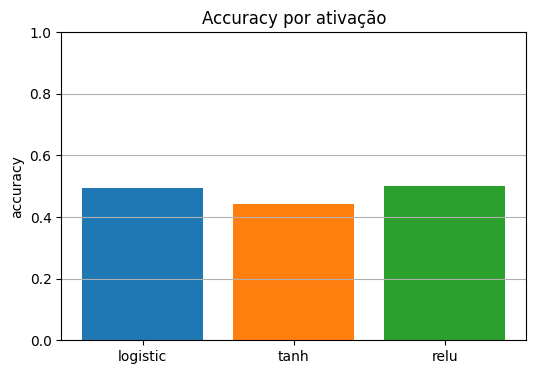

In [17]:
df = results_activations
plt.figure(figsize=(6,4))
plt.bar(df['activation'].astype(str), df['accuracy'], color=['#1f77b4','#ff7f0e','#2ca02c'])
plt.title('Accuracy por ativação')
plt.ylabel('accuracy')
plt.ylim(0,1)
plt.grid(axis='y')
plt.show()

**Respostas**:

1. **Qual ativação apresentou melhor convergência?**
relu — apresentou as melhores métricas (maior accuracy e f1), indicando convergência mais favorável no conjunto de validação.

2. **Qual ativação apresentou maior estabilidade?**
relu (mais alta e balanceada); logistic é próxima; tanh mostrou menor desempenho e menos estabilidade.

3. **Houve diferenças significativas no treinamento?**
Pequena diferença entre relu e logistic (0.0045 em accuracy), portanto não muito significativa; porém tanh foi claramente pior (0.0565 menor em accuracy vs relu), então há diferença relevante entre tanh e as demais.

4. **Por que a ReLU é amplamente utilizada em Deep Learning?**
simplicidade computacional, ativações esparsas, ajuda a mitigar o vanishing gradient e costuma acelerar convergência em redes profundas.

# Questão 6

Compare as seguintes arquiteturas:

```python
(32,)
(64,)
(128, 64)
(256, 128)
```

## Requisitos

Para cada arquitetura:

- treine;
- avalie;
- registre no MLflow.

Analise:

- accuracy;
- custo computacional;
- estabilidade;
- overfitting.

Responda:

1. Redes maiores sempre melhoraram os resultados?
2. Qual arquitetura apresentou melhor tradeoff?
3. Houve sinais de overfitting?
4. Qual arquitetura apresentou maior custo computacional?

**Solução**:

In [20]:
def compare_architectures(
    X_train,
    y_train,
    X_val,
    y_val,
    activation=None,
    activations=("logistic", "tanh", "relu"),
    learning_rate=0.001,
    seed=42,
    architectures=((32,), (64,), (128, 64), (256, 128)),
    max_iter=200,
    batch_size=64,
):
    rows = []
    # determine which activations to run: explicit activations override single activation
    if activations is None:
        activations = (activation,) if activation is not None else ("relu",)
    for act in activations:
        for hidden_layers in architectures:
            _, metrics, training_time = log_mlp_experiment(
                X_train,
                y_train,
                X_val,
                y_val,
                activation=act,
                hidden_layers=hidden_layers,
                learning_rate=learning_rate,
                seed=seed,
                max_iter=max_iter,
                batch_size=batch_size,
                run_name=f"architecture={hidden_layers}_activation={act}",
            )
            rows.append({"activation": act, "hidden_layers": hidden_layers, **metrics, "training_time": training_time})
    return pd.DataFrame(rows)

In [21]:

X_train, X_val, y_train, y_val = load_data(seed=42)
architectures = ((32,), (64,), (128,64), (256,128))
results_arch = compare_architectures(
    X_train, y_train, X_val, y_val,
    activation=None,
    learning_rate=0.001,
    seed=42,
    architectures=architectures,
    max_iter=50,
    batch_size=128,
)
print(results_arch)
results_arch

2026/05/24 19:19:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 19:19:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/24 19:21:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 19:21:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

2026/05/24 19:19:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 19:19:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/24 19:21:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 19:21:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

   activation hidden_layers  accuracy  precision  recall  f1_score  \
0    logistic         (32,)    0.4663   0.461236  0.4663  0.459511   
1    logistic         (64,)    0.4785   0.488209  0.4785  0.473405   
2    logistic     (128, 64)    0.4956   0.496608  0.4956  0.492102   
3    logistic    (256, 128)    0.4959   0.495952  0.4959  0.489392   
4        tanh         (32,)    0.4219   0.426968  0.4219  0.414626   
5        tanh         (64,)    0.4388   0.453577  0.4388  0.439239   
6        tanh     (128, 64)    0.4436   0.454683  0.4436  0.440890   
7        tanh    (256, 128)    0.4536   0.471618  0.4536  0.452346   
8        relu         (32,)    0.3943   0.386604  0.3943  0.379119   
9        relu         (64,)    0.3863   0.381017  0.3863  0.375584   
10       relu     (128, 64)    0.5001   0.506052  0.5001  0.499646   
11       relu    (256, 128)    0.5039   0.506698  0.5039  0.500032   

    training_time  
0       67.961293  
1      128.042442  
2      349.387773  
3      66

,activation,hidden_layers,accuracy,precision,recall,f1_score,training_time
0,logistic,"(32,)",0.4663,0.461236,0.4663,0.459511,67.961293
1,logistic,"(64,)",0.4785,0.488209,0.4785,0.473405,128.042442
2,logistic,"(128, 64)",0.4956,0.496608,0.4956,0.492102,349.387773
3,logistic,"(256, 128)",0.4959,0.495952,0.4959,0.489392,664.146278
4,tanh,"(32,)",0.4219,0.426968,0.4219,0.414626,73.137198
5,tanh,"(64,)",0.4388,0.453577,0.4388,0.439239,105.730698
6,tanh,"(128, 64)",0.4436,0.454683,0.4436,0.440890,294.312695
7,tanh,"(256, 128)",0.4536,0.471618,0.4536,0.452346,487.972481
8,relu,"(32,)",0.3943,0.386604,0.3943,0.379119,124.583552
9,relu,"(64,)",0.3863,0.381017,0.3863,0.375584,195.062700


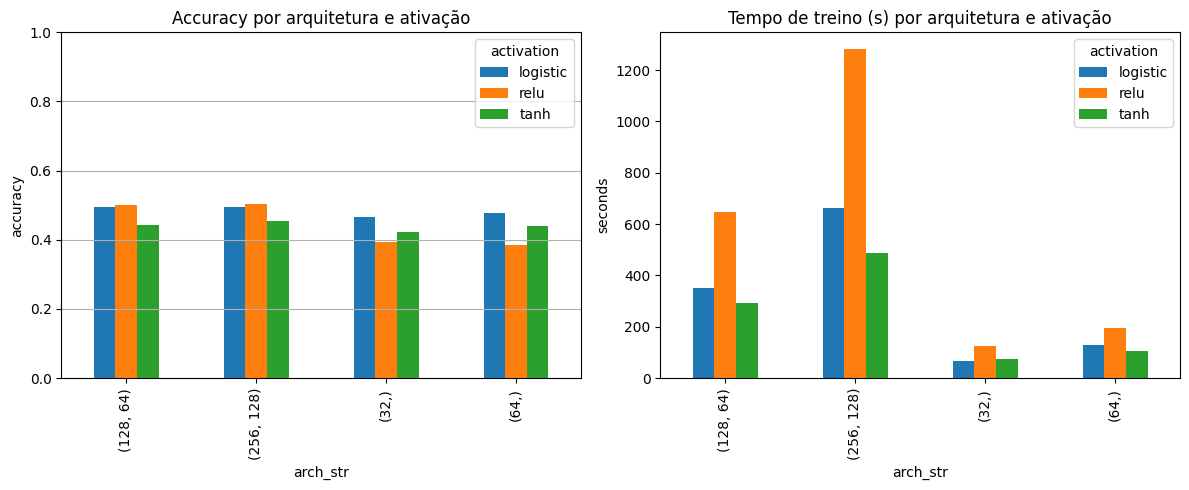

In [22]:
df = results_arch.copy()
df['arch_str'] = df['hidden_layers'].astype(str)
pivot_acc = df.pivot(index='arch_str', columns='activation', values='accuracy')
pivot_time = df.pivot(index='arch_str', columns='activation', values='training_time')
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
pivot_acc.plot(kind='bar', ax=plt.gca())
plt.title('Accuracy por arquitetura e ativação')
plt.ylim(0,1)
plt.ylabel('accuracy')
plt.grid(axis='y')
plt.subplot(1,2,2)
pivot_time.plot(kind='bar', ax=plt.gca())
plt.title('Tempo de treino (s) por arquitetura e ativação')
plt.ylabel('seconds')
plt.tight_layout()
plt.show()

**Respostas (Questão 6)**:

1. **Redes maiores sempre melhoraram os resultados?**
   Não. Embora as arquiteturas maiores tenham apresentado melhora em vários casos, o ganho não ocorreu de forma proporcional ao aumento do custo computacional. Com ReLU, por exemplo, a arquitetura (64,) obteve accuracy de 0.3863, inferior à arquitetura menor (32,), que obteve 0.3943. Já a arquitetura (256, 128) apresentou o melhor resultado geral, com accuracy de 0.5039, mas a melhora em relação à arquitetura (128, 64), que alcançou 0.5001, foi pequena.

2. **Qual arquitetura apresentou melhor tradeoff?**
    A arquitetura (128, 64) apresentou o melhor tradeoff entre desempenho e custo computacional. Utilizando ReLU, ela obteve accuracy de 0.5001 e f1-score de 0.4996, valores muito próximos aos da arquitetura maior (256, 128), que obteve accuracy de 0.5039 e f1-score de 0.5000. Entretanto, o tempo de treinamento aumentou de aproximadamente 645,35 segundos para 1282,65 segundos, quase dobrando para um ganho muito pequeno de accuracy.

3. **Houve sinais de overfitting?**
   Com os resultados apresentados, não é possível confirmar overfitting, pois foram registradas apenas métricas no conjunto de validação, sem comparação com accuracy ou loss de treinamento. Para avaliar overfitting adequadamente, seria necessário observar se o desempenho no treino continua melhorando enquanto o desempenho na validação piora ou permanece estagnado. Ainda assim, o pequeno ganho das redes maiores sugere que aumentar a complexidade não trouxe benefícios significativos de generalização.


4. **Qual arquitetura apresentou maior custo computacional?**
   A arquitetura (256, 128) apresentou o maior custo computacional em todas as ativações testadas. O maior tempo observado ocorreu com a ativação ReLU, totalizando aproximadamente 1282,65 segundos de treinamento. Em comparação, a arquitetura (128, 64) com ReLU levou aproximadamente 645,35 segundos.



# Questão 7

Compare os seguintes learning rates:

```python
0.1
0.01
0.001
```

## Requisitos

Utilize:

- mesma arquitetura;
- mesma ativação;
- mesma seed.

Para cada experimento:

- treine;
- avalie;
- registre no MLflow.

Analise:

- estabilidade;
- convergência;
- accuracy;
- comportamento da loss.

Responda:

1. Qual learning rate apresentou melhor desempenho?
2. Qual apresentou maior instabilidade?
3. O que acontece quando o learning rate é muito alto?
4. O que acontece quando o learning rate é muito baixo?

In [24]:
def compare_learning_rates(
    X_train,
    y_train,
    X_val,
    y_val,
    activation="relu",
    hidden_layers=(128, 64),
    seed=42,
    learning_rates=(0.1, 0.01, 0.001),
    max_iter=200,
    batch_size=64,
):
    rows = []
    for learning_rate in learning_rates:
        _, metrics, training_time = log_mlp_experiment(
            X_train,
            y_train,
            X_val,
            y_val,
            activation=activation,
            hidden_layers=hidden_layers,
            learning_rate=learning_rate,
            seed=seed,
            max_iter=max_iter,
            batch_size=batch_size,
            run_name=f"learning_rate={learning_rate}",
        )
        rows.append({"learning_rate": learning_rate, **metrics, "training_time": training_time})
    return pd.DataFrame(rows)

In [25]:
X_train, X_val, y_train, y_val = load_data(seed=42)
learning_rates = (0.1, 0.01, 0.001)
results_lr = compare_learning_rates(
    X_train, y_train, X_val, y_val,
    activation='relu',
    hidden_layers=(128,64),
    seed=42,
    learning_rates=learning_rates,
    max_iter=50,
    batch_size=128,
)
print(results_lr)
results_lr

2026/05/24 20:57:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 20:57:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/24 21:10:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 21:10:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

   learning_rate  accuracy  precision  recall  f1_score  training_time
0          0.100    0.1000   0.010000  0.1000  0.018182     848.349637
1          0.010    0.4000   0.410474  0.4000  0.385782     809.545264
2          0.001    0.5001   0.506052  0.5001  0.499646     600.543315


,learning_rate,accuracy,precision,recall,f1_score,training_time
0,0.100,0.1000,0.010000,0.1000,0.018182,848.349637
1,0.010,0.4000,0.410474,0.4000,0.385782,809.545264
2,0.001,0.5001,0.506052,0.5001,0.499646,600.543315


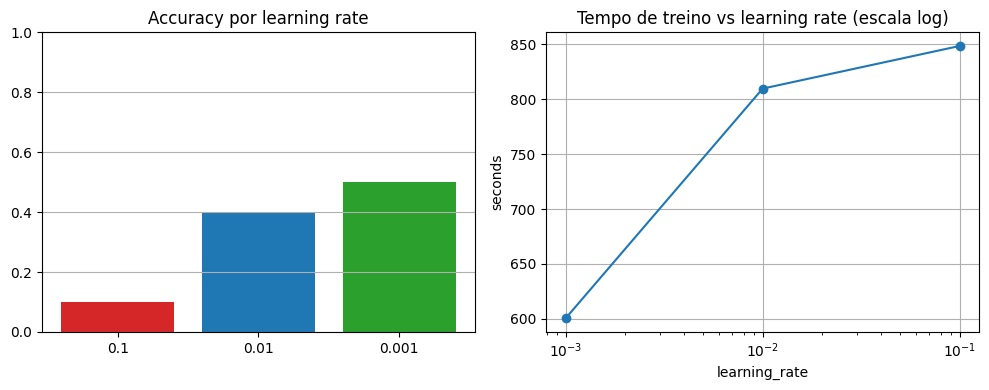

In [26]:
df = results_lr.copy()
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.bar(df['learning_rate'].astype(str), df['accuracy'], color=['#d62728','#1f77b4','#2ca02c'])
plt.title('Accuracy por learning rate')
plt.ylim(0,1)
plt.grid(axis='y')
plt.subplot(1,2,2)
plt.plot(df['learning_rate'], df['training_time'], marker='o')
plt.xscale('log')
plt.title('Tempo de treino vs learning rate (escala log)')
plt.xlabel('learning_rate')
plt.ylabel('seconds')
plt.grid(True)
plt.tight_layout()
plt.show()

**Respostas (Questão 7)**:

1. **Qual learning rate apresentou melhor desempenho?**
   O learning rate 0.001 apresentou o melhor desempenho. Utilizando a arquitetura (128, 64) com ativação ReLU, ele obteve accuracy de 0.5001, precision de 0.5061, recall de 0.5001 e f1-score de 0.4996. Esses valores foram superiores aos obtidos com 0.01 e 0.1.

2. **Qual apresentou maior instabilidade?**
   O learning rate 0.1 apresentou o pior comportamento e pode ser considerado o mais instável entre os valores testados. Sua accuracy foi de apenas 0.1000, equivalente ao nível de acerto esperado por acaso em um problema com 10 classes balanceadas, como o CIFAR-10. Isso indica que o modelo praticamente não conseguiu aprender uma representação útil.

3. **O que acontece quando o learning rate é muito alto?**
   Quando o learning rate é muito alto, as atualizações dos pesos tornam-se grandes demais. Dessa forma, o otimizador pode ultrapassar regiões adequadas da função de erro, oscilar durante o treinamento ou não convergir. Neste experimento, isso ocorreu com 0.1, que resultou em accuracy de apenas 0.1000 e f1-score de 0.0182.
  
4. **O que acontece quando o learning rate é muito baixo?**
  Quando o learning rate é muito baixo, as atualizações dos pesos tornam-se pequenas, fazendo com que o treinamento avance lentamente e possa exigir mais épocas para convergir. Entretanto, entre os valores avaliados neste experimento, 0.001 não se mostrou excessivamente baixo: ele foi justamente o valor que proporcionou o melhor desempenho final.

# Questão 8

Com base nos experimentos realizados, escreva uma discussão contendo:

- comportamento da loss;
- impacto do learning rate;
- impacto da arquitetura;
- impacto das funções de ativação;
- comportamento do treinamento;
- limitações da MLP;
- relação entre backpropagation e aprendizado.

Além disso, responda:

1. Qual configuração apresentou melhor resultado final?
2. Quais foram as principais dificuldades observadas?
3. Por que MLPs possuem limitações para imagens?
4. Como o backpropagation contribui para o aprendizado da rede?

**Respostas**:

1. **Qual configuração apresentou melhor resultado final?**
A configuração que apresentou o melhor resultado final foi a arquitetura (256, 128), com ativação relu, learning rate 0.001, seed 42, max_iter=50 e batch_size=128. Essa configuração obteve accuracy de 0.5039, precision de 0.5067, recall de 0.5039 e f1-score de 0.5000.

2. **Quais foram as principais dificuldades observadas?**
As principais dificuldades foram o elevado custo computacional das arquiteturas maiores, a sensibilidade do modelo ao learning rate e o desempenho limitado da MLP na classificação de imagens do CIFAR-10. Além disso, a ausência de curvas de loss e de métricas separadas para treino e validação limita uma análise mais precisa de convergência, estabilidade e overfitting.

3. **Por que MLPs possuem limitações para imagens?**
MLPs possuem limitações para imagens porque trabalham com os pixels transformados em um vetor por meio do flatten, perdendo a estrutura espacial original da imagem. Dessa forma, a rede não explora adequadamente padrões locais, como bordas, texturas e formas. Além disso, as camadas totalmente conectadas geram uma grande quantidade de parâmetros, aumentando o custo do treinamento.

4. **Como o backpropagation contribui para o aprendizado da rede?**
O backpropagation calcula os gradientes do erro em relação aos pesos da rede e propaga essa informação das camadas de saída para as camadas anteriores. Com esses gradientes, o otimizador ajusta os pesos para reduzir a função de perda. Esse processo permite que a rede aprenda padrões nos dados e melhore seu desempenho ao longo das iterações.